# ***Домашняя работа №7***
## Терёшин Кирилл
### БФБО-02-24

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score
from sklearn.pipeline import Pipeline

plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style("whitegrid")

In [3]:
DATA_PATH = Path("data")
ARTIFACTS_PATH = Path("artifacts")
ARTIFACTS_PATH.mkdir(exist_ok=True)
(ARTIFACTS_PATH / "figures").mkdir(exist_ok=True)
(ARTIFACTS_PATH / "labels").mkdir(exist_ok=True)

# ***2.3.1. Загрузка данных и первичный анализ (для каждого датасета)***

2.3.1. ЗАГРУЗКА ДАННЫХ И ПЕРВИЧНЫЙ АНАЛИЗ

ДАТАСЕТ: S07-hw-dataset-01.csv
1. Первые 5 строк:


,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
0,0,-0.536647,-69.812900,-0.002657,71.743147,-11.396498,-12.291287,-6.836847,-0.504094
1,1,15.230731,52.727216,-1.273634,-104.123302,11.589643,34.316967,-49.468873,0.390356
2,2,18.542693,77.317150,-1.321686,-111.946636,10.254346,25.892951,44.595250,0.325893
3,3,-12.538905,-41.709458,0.146474,16.322124,1.391137,2.014316,-39.930582,0.139297
4,4,-6.903056,61.833444,-0.022466,-42.631335,3.107154,-5.471054,7.001149,0.131213



2. Информация о датасете:


,Тип,Уникальных значений,Пропусков,Доля пропусков (%)
sample_id,int64,12000,0,0.0
f01,float64,12000,0,0.0
f02,float64,12000,0,0.0
f03,float64,12000,0,0.0
f04,float64,12000,0,0.0
f05,float64,12000,0,0.0
f06,float64,12000,0,0.0
f07,float64,12000,0,0.0
f08,float64,12000,0,0.0



3. Базовые статистики (числовые признаки):


...


2. Информация о датасете:


,Тип,Уникальных значений,Пропусков,Доля пропусков (%)
sample_id,int64,15000,0,0.0
x1,float64,15000,0,0.0
x2,float64,15000,0,0.0
f_corr,float64,15000,0,0.0
f_noise,float64,15000,0,0.0



3. Базовые статистики (числовые признаки):


,x1,x2,f_corr,f_noise
count,15000.000,15000.000,15000.000,15000.000
mean,1.246,1.034,0.213,-0.027
std,4.592,4.711,1.530,2.506
min,-9.996,-9.981,-5.212,-8.786
25%,-1.782,-2.666,-0.966,-1.731
50%,0.664,1.831,0.297,-0.052
75%,4.436,4.970,1.390,1.674
max,16.208,14.271,5.796,11.267



4. Проверка пропусков:
Общее количество пропусков: 0
Доля пропусков: 0.0%

5. Анализ типов признаков:
Числовые признаки (4):
  - x1 (тип: float64)
  - x2 (тип: float64)
  - f_corr (тип: float64)
  - f_noise (тип: float64)

Категориальные признаки (0):

6. Подготовка данных для кластеризации:
  sample_id сохранен отдельно (15000 записей)
  Признаки (X): 4 колонок, 15000 записей
  Колонки X: ['x1', 'x2', 'f_corr', 'f_noise']

Общая информация:
  Всего записей: 15000
  Всего признаков: 5
  Числовых признаков: 4
  Категориальных признаков: 0

ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЙ: S07-hw-dataset-01.csv


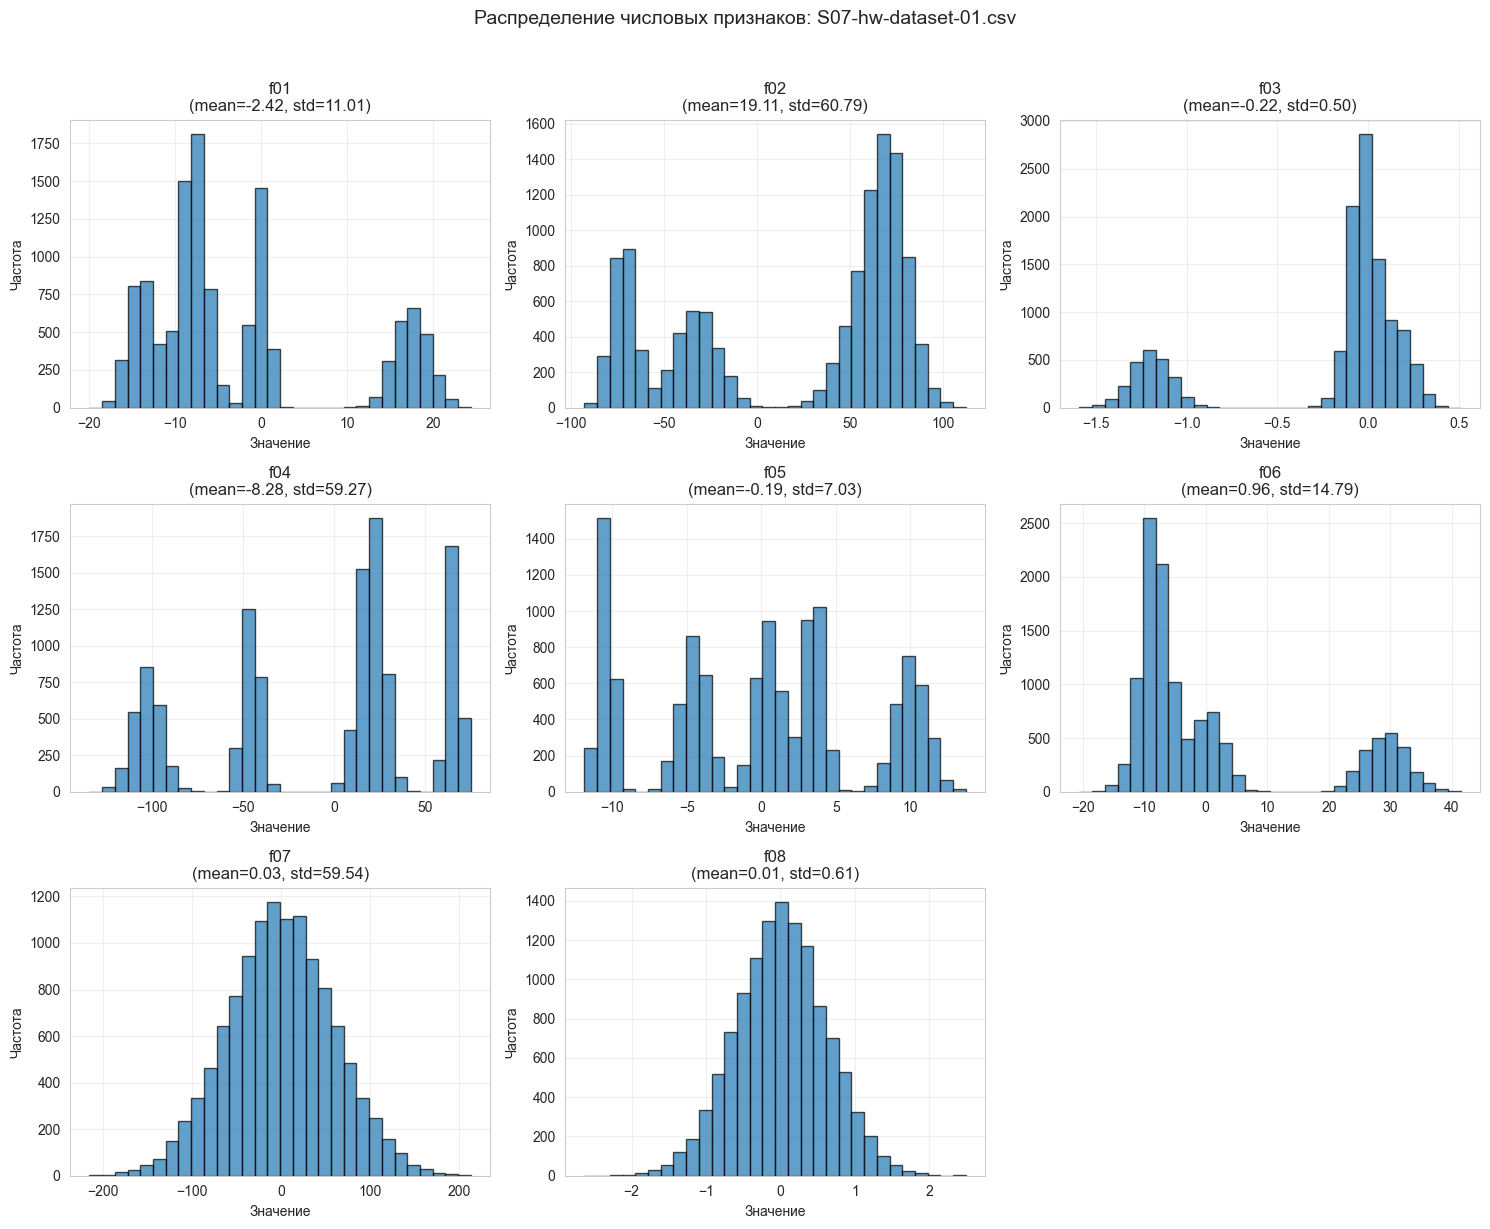


ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЙ: S07-hw-dataset-02.csv


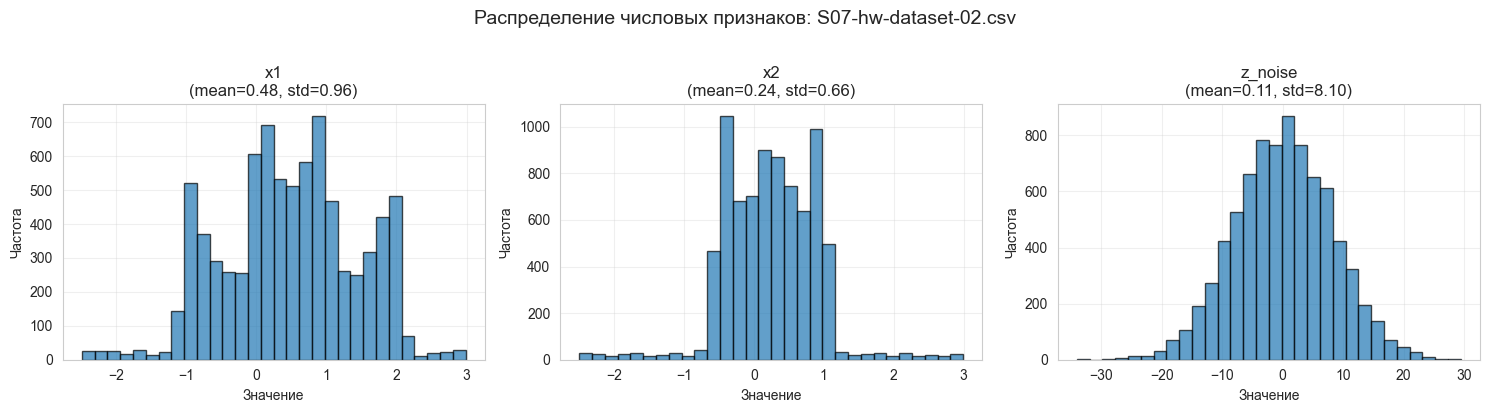


ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЙ: S07-hw-dataset-03.csv


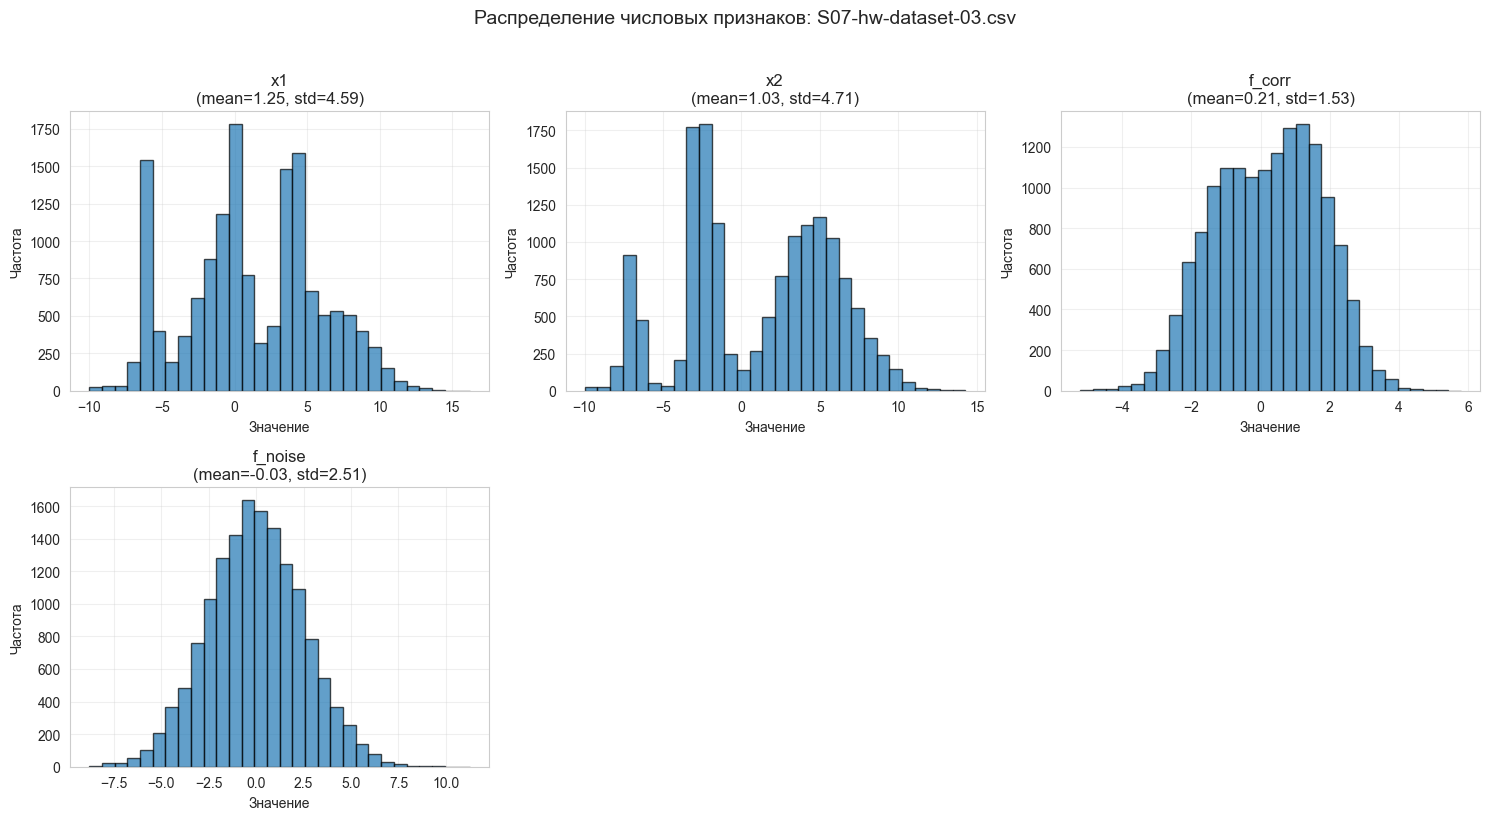


ПЕРВИЧНЫЙ АНАЛИЗ ЗАВЕРШЕН


In [4]:
print("="*80)
print("2.3.1. ЗАГРУЗКА ДАННЫХ И ПЕРВИЧНЫЙ АНАЛИЗ")
print("="*80)

# Загрузка датасетов
dataset_names = ['S07-hw-dataset-01.csv', 'S07-hw-dataset-02.csv', 'S07-hw-dataset-03.csv']
datasets = {}
sample_ids = {}
X_dict = {}

for name in dataset_names:
    print(f"\n{'='*60}")
    print(f"ДАТАСЕТ: {name}")
    print('='*60)
    
    # Загрузка CSV
    df = pd.read_csv(DATA_PATH / name)
    datasets[name] = df
    
    # 1. Первые 5 строк
    print("1. Первые 5 строк:")
    display(df.head())
    
    # 2. Информация о датасете
    print("\n2. Информация о датасете:")
    df_info = pd.DataFrame({
        'Тип': df.dtypes,
        'Уникальных значений': df.nunique(),
        'Пропусков': df.isnull().sum(),
        'Доля пропусков (%)': (df.isnull().sum() / len(df) * 100).round(2)
    })
    display(df_info)
    
    # 3. Базовые статистики для числовых признаков
    print("\n3. Базовые статистики (числовые признаки):")
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if 'sample_id' in numeric_cols:
        numeric_cols.remove('sample_id')
    
    if numeric_cols:
        display(df[numeric_cols].describe().round(3))
    else:
        print("Нет числовых признаков")
    
    # 4. Проверка пропусков
    print("\n4. Проверка пропусков:")
    missing_total = df.isnull().sum().sum()
    missing_pct = (missing_total / (df.shape[0] * df.shape[1]) * 100).round(2)
    print(f"Общее количество пропусков: {missing_total}")
    print(f"Доля пропусков: {missing_pct}%")
    
    # Вывод признаков с пропусками
    missing_cols = df.columns[df.isnull().any()].tolist()
    if missing_cols:
        print("Признаки с пропусками:")
        for col in missing_cols:
            missing_count = df[col].isnull().sum()
            missing_percent = (missing_count / len(df) * 100).round(2)
            print(f"  {col}: {missing_count} пропусков ({missing_percent}%)")
    
    # 5. Типы признаков
    print("\n5. Анализ типов признаков:")
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    print(f"Числовые признаки ({len(numeric_cols)}):")
    for col in numeric_cols:
        if col != 'sample_id':
            print(f"  - {col} (тип: {df[col].dtype})")
    
    print(f"\nКатегориальные признаки ({len(categorical_cols)}):")
    for col in categorical_cols:
        print(f"  - {col} (тип: {df[col].dtype}, уникальных значений: {df[col].nunique()})")
    
    # 6. Определение X и sample_id
    print("\n6. Подготовка данных для кластеризации:")
    if 'sample_id' in df.columns:
        sample_ids[name] = df['sample_id'].copy()
        # X - все признаки кроме sample_id
        feature_cols = [col for col in df.columns if col != 'sample_id']
        X = df[feature_cols].copy()
        X_dict[name] = X
        print(f"  sample_id сохранен отдельно ({len(sample_ids[name])} записей)")
        print(f"  Признаки (X): {len(feature_cols)} колонок, {X.shape[0]} записей")
        print(f"  Колонки X: {feature_cols}")
    else:
        print("  ВНИМАНИЕ: sample_id не найден в датасете!")
        X_dict[name] = df.copy()
    
    print(f"\nОбщая информация:")
    print(f"  Всего записей: {df.shape[0]}")
    print(f"  Всего признаков: {df.shape[1]}")
    print(f"  Числовых признаков: {len(numeric_cols)}")
    print(f"  Категориальных признаков: {len(categorical_cols)}")

# Визуализация распределения числовых признаков для каждого датасета
for name, df in datasets.items():
    print(f"\n{'='*60}")
    print(f"ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЙ: {name}")
    print('='*60)
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if 'sample_id' in numeric_cols:
        numeric_cols.remove('sample_id')
    
    if numeric_cols:
        n_cols = len(numeric_cols)
        n_rows = (n_cols + 2) // 3  # 3 колонки в ряду
        
        fig, axes = plt.subplots(n_rows, 3, figsize=(15, n_rows*4))
        axes = axes.flatten()
        
        for idx, col in enumerate(numeric_cols):
            if idx < len(axes):
                ax = axes[idx]
                # Гистограмма
                df[col].hist(ax=ax, bins=30, edgecolor='black', alpha=0.7)
                ax.set_title(f'{col}\n(mean={df[col].mean():.2f}, std={df[col].std():.2f})')
                ax.set_xlabel('Значение')
                ax.set_ylabel('Частота')
                ax.grid(True, alpha=0.3)
        
        # Скрываем пустые subplots
        for idx in range(len(numeric_cols), len(axes)):
            axes[idx].set_visible(False)
        
        plt.suptitle(f'Распределение числовых признаков: {name}', fontsize=14, y=1.02)
        plt.tight_layout()
        plt.savefig(ARTIFACTS_PATH / "figures" / f"distributions_{name.replace('.csv', '')}.png", 
                   dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print("Нет числовых признаков для визуализации")

print("\n" + "="*80)
print("ПЕРВИЧНЫЙ АНАЛИЗ ЗАВЕРШЕН")
print("="*80)

# ***2.3.2. Препроцессинг (обязательно)***

In [5]:
print("\n" + "="*80)
print("2.3.2. ПРЕПРОЦЕССИНГ")
print("="*80)

# Функция препроцессинга
def preprocess_data(df, dataset_name):
    print(f"\nПрепроцессинг для {dataset_name}:")
    
    # Выделяем sample_id если он есть
    if 'sample_id' in df.columns:
        sample_ids_local = df['sample_id'].copy()
        X = df.drop('sample_id', axis=1)
    else:
        sample_ids_local = pd.Series(range(len(df)))  # создаем временные ID
        X = df.copy()
    
    # Разделяем числовые и категориальные признаки
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    
    print(f"  Числовых признаков: {len(numeric_cols)}")
    print(f"  Категориальных признаков: {len(categorical_cols)}")
    
    # Для HW07 датасетов категориальных признаков нет, но оставим обработку
    if len(categorical_cols) > 0:
        print(f"  ВНИМАНИЕ: Обнаружены категориальные признаки: {categorical_cols}")
        print("  Для этого задания используем только числовые признаки")
        X = X[numeric_cols]  # используем только числовые признаки
    
    # Пайплайн препроцессинга
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    # Применяем препроцессинг
    X_processed = pipeline.fit_transform(X)
    
    print(f"  Исходная форма: {X.shape}")
    print(f"  После препроцессинга: {X_processed.shape}")
    print(f"  Использованные стратегии:")
    print(f"    - Обработка пропусков: median imputation")
    print(f"    - Масштабирование: StandardScaler")
    
    return X_processed, sample_ids_local, pipeline, X.columns.tolist()

# Препроцессинг всех датасетов
processed_data = {}
for name, df in datasets.items():
    X_processed, ids, preprocessor, feature_names = preprocess_data(df, name)
    processed_data[name] = {
        'X': X_processed, 
        'ids': ids, 
        'preprocessor': preprocessor,
        'feature_names': feature_names
    }

print("\n" + "="*80)
print("ПРЕПРОЦЕССИНГ ЗАВЕРШЕН")
print("="*80)


2.3.2. ПРЕПРОЦЕССИНГ

Препроцессинг для S07-hw-dataset-01.csv:
  Числовых признаков: 8
  Категориальных признаков: 0
  Исходная форма: (12000, 8)
  После препроцессинга: (12000, 8)
  Использованные стратегии:
    - Обработка пропусков: median imputation
    - Масштабирование: StandardScaler

Препроцессинг для S07-hw-dataset-02.csv:
  Числовых признаков: 3
  Категориальных признаков: 0
  Исходная форма: (8000, 3)
  После препроцессинга: (8000, 3)
  Использованные стратегии:
    - Обработка пропусков: median imputation
    - Масштабирование: StandardScaler

Препроцессинг для S07-hw-dataset-03.csv:
  Числовых признаков: 4
  Категориальных признаков: 0
  Исходная форма: (15000, 4)
  После препроцессинга: (15000, 4)
  Использованные стратегии:
    - Обработка пропусков: median imputation
    - Масштабирование: StandardScaler

ПРЕПРОЦЕССИНГ ЗАВЕРШЕН


# Вспомогательные функции для кластеризации

In [6]:
def evaluate_clustering(X, labels):
    """Оценка качества кластеризации"""
    if -1 in labels:  # Для DBSCAN (шумовые точки)
        mask = labels != -1
        noise_ratio = 1 - np.mean(mask)
        X_eval = X[mask] if np.sum(mask) > 1 else X
        labels_eval = labels[mask] if np.sum(mask) > 1 else labels
    else:
        noise_ratio = 0
        X_eval = X
        labels_eval = labels
    
    metrics = {}
    if len(np.unique(labels_eval)) > 1:
        metrics['silhouette'] = float(silhouette_score(X_eval, labels_eval))
        metrics['davies_bouldin'] = float(davies_bouldin_score(X_eval, labels_eval))
        metrics['calinski_harabasz'] = float(calinski_harabasz_score(X_eval, labels_eval))
    else:
        metrics['silhouette'] = 0.0
        metrics['davies_bouldin'] = float('inf')
        metrics['calinski_harabasz'] = 0.0
    
    metrics['noise_ratio'] = float(noise_ratio)
    metrics['n_clusters'] = int(len(np.unique(labels_eval)))
    return metrics

def plot_pca_clusters(X, labels, title, filename):
    """Визуализация кластеров в PCA"""
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X)
    
    plt.figure(figsize=(10, 6))
    unique_labels = np.unique(labels)
    
    for label in unique_labels:
        if label == -1:  # Шумовые точки для DBSCAN
            mask = labels == label
            plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                       c='gray', alpha=0.3, s=20, label='Noise')
        else:
            mask = labels == label
            plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                       alpha=0.7, s=30, label=f'Cluster {label}')
    
    plt.title(f'{title}')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(ARTIFACTS_PATH / "figures" / filename, dpi=150, bbox_inches='tight')
    plt.close()


# ***2.3.3. Модели недели 7 (для каждого датасета – минимум 2 алгоритма)***


2.3.3. МОДЕЛИ КЛАСТЕРИЗАЦИИ

ДАТАСЕТ 01: KMeans + DBSCAN

1. KMeans - подбор оптимального k:


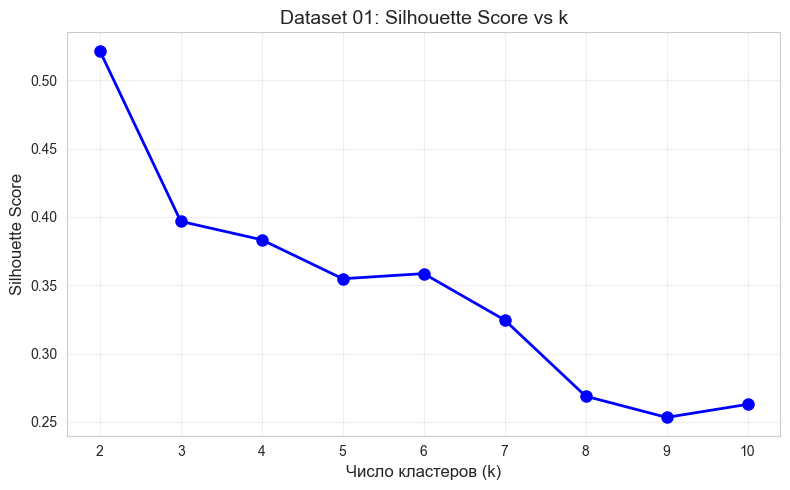

  Лучшее k: 2 (silhouette = 0.522)

2. DBSCAN:
  Параметры: eps=0.5, min_samples=5
  Обнаружено кластеров: 9
  Доля шума: 3.4%

ДАТАСЕТ 02: KMeans + AgglomerativeClustering

1. KMeans:

2. AgglomerativeClustering - сравнение linkage методов:
  ward: silhouette = 0.208
  complete: silhouette = 0.200
  average: silhouette = 0.305


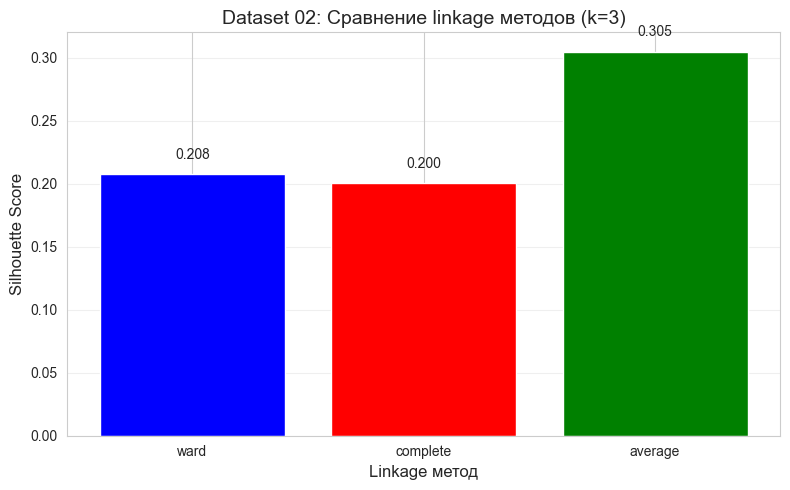


  Лучший linkage: average

ДАТАСЕТ 03: KMeans + DBSCAN

1. KMeans:

2. DBSCAN - подбор eps:
  eps=0.2: silhouette = -0.126
  eps=0.3: silhouette = -0.236
  eps=0.4: silhouette = -0.040
  eps=0.5: silhouette = -0.104


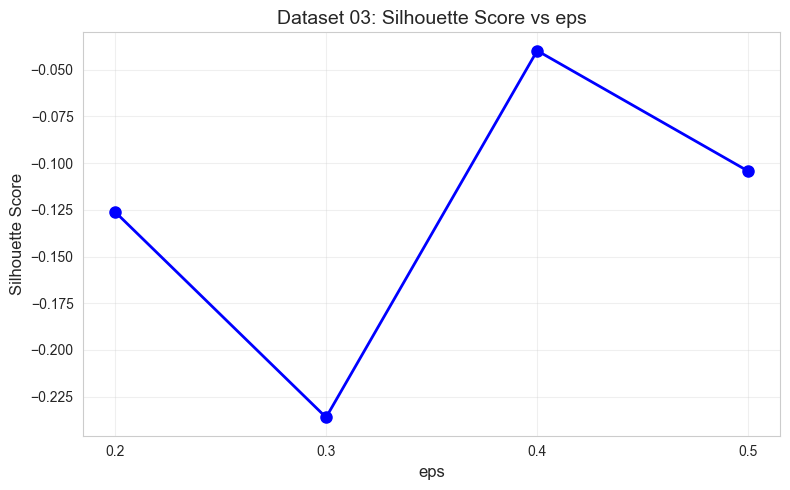


  Лучший eps: 0.4
  Обнаружено кластеров: 6
  Доля шума: 5.0%


In [7]:
print("\n" + "="*80)
print("2.3.3. МОДЕЛИ КЛАСТЕРИЗАЦИИ")
print("="*80)

# Словарь для хранения всех результатов
all_results = {}

# --- Датасет 01: KMeans + DBSCAN ---
print("\n" + "="*60)
print("ДАТАСЕТ 01: KMeans + DBSCAN")
print("="*60)

name = 'S07-hw-dataset-01.csv'
X = processed_data[name]['X']

print("\n1. KMeans - подбор оптимального k:")
k_range = range(2, 11)
silhouettes = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    if len(np.unique(labels)) > 1:
        silhouettes.append(silhouette_score(X, labels))
    else:
        silhouettes.append(0)

# График silhouette vs k
plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouettes, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Число кластеров (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Dataset 01: Silhouette Score vs k', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.tight_layout()
plt.savefig(ARTIFACTS_PATH / "figures" / "dataset01_silhouette_vs_k.png", 
           dpi=150, bbox_inches='tight')
plt.show()

# Лучший KMeans
best_k = k_range[np.argmax(silhouettes)]
print(f"  Лучшее k: {best_k} (silhouette = {max(silhouettes):.3f})")

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)
kmeans_metrics = evaluate_clustering(X, kmeans_labels)

print(f"\n2. DBSCAN:")
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)
dbscan_metrics = evaluate_clustering(X, dbscan_labels)

print(f"  Параметры: eps=0.5, min_samples=5")
print(f"  Обнаружено кластеров: {dbscan_metrics['n_clusters']}")
print(f"  Доля шума: {dbscan_metrics['noise_ratio']:.1%}")

# Сохранение результатов
all_results[name] = {
    'KMeans': {'metrics': kmeans_metrics, 'labels': kmeans_labels, 'params': {'k': best_k}},
    'DBSCAN': {'metrics': dbscan_metrics, 'labels': dbscan_labels, 'params': {'eps': 0.5, 'min_samples': 5}}
}

# --- Датасет 02: KMeans + AgglomerativeClustering ---
print("\n" + "="*60)
print("ДАТАСЕТ 02: KMeans + AgglomerativeClustering")
print("="*60)

name = 'S07-hw-dataset-02.csv'
X = processed_data[name]['X']

print("\n1. KMeans:")
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)
kmeans_metrics = evaluate_clustering(X, kmeans_labels)

print("\n2. AgglomerativeClustering - сравнение linkage методов:")
linkages = ['ward', 'complete', 'average']
agg_scores = []

for linkage in linkages:
    agg = AgglomerativeClustering(n_clusters=3, linkage=linkage)
    labels = agg.fit_predict(X)
    if len(np.unique(labels)) > 1:
        score = silhouette_score(X, labels)
    else:
        score = 0
    agg_scores.append(score)
    print(f"  {linkage}: silhouette = {score:.3f}")

# График сравнения linkage методов
plt.figure(figsize=(8, 5))
bars = plt.bar(linkages, agg_scores, color=['blue', 'red', 'green'])
plt.xlabel('Linkage метод', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Dataset 02: Сравнение linkage методов (k=3)', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for bar, score in zip(bars, agg_scores):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{score:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(ARTIFACTS_PATH / "figures" / "dataset02_linkage_comparison.png", 
           dpi=150, bbox_inches='tight')
plt.show()

# Лучший AgglomerativeClustering
best_linkage = linkages[np.argmax(agg_scores)]
agg = AgglomerativeClustering(n_clusters=3, linkage=best_linkage)
agg_labels = agg.fit_predict(X)
agg_metrics = evaluate_clustering(X, agg_labels)

print(f"\n  Лучший linkage: {best_linkage}")

# Сохранение результатов
all_results[name] = {
    'KMeans': {'metrics': kmeans_metrics, 'labels': kmeans_labels, 'params': {'k': 3}},
    'Agglomerative': {'metrics': agg_metrics, 'labels': agg_labels, 
                      'params': {'n_clusters': 3, 'linkage': best_linkage}}
}

# --- Датасет 03: KMeans + DBSCAN ---
print("\n" + "="*60)
print("ДАТАСЕТ 03: KMeans + DBSCAN")
print("="*60)

name = 'S07-hw-dataset-03.csv'
X = processed_data[name]['X']

print("\n1. KMeans:")
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)
kmeans_metrics = evaluate_clustering(X, kmeans_labels)

print("\n2. DBSCAN - подбор eps:")
eps_values = [0.2, 0.3, 0.4, 0.5]
dbscan_scores = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X)
    if -1 in labels:
        mask = labels != -1
        if np.sum(mask) > 1:
            score = silhouette_score(X[mask], labels[mask])
        else:
            score = 0
    else:
        score = silhouette_score(X, labels) if len(np.unique(labels)) > 1 else 0
    dbscan_scores.append(score)
    print(f"  eps={eps}: silhouette = {score:.3f}")

# График silhouette vs eps
plt.figure(figsize=(8, 5))
plt.plot(eps_values, dbscan_scores, 'bo-', linewidth=2, markersize=8)
plt.xlabel('eps', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Dataset 03: Silhouette Score vs eps', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(eps_values)
plt.tight_layout()
plt.savefig(ARTIFACTS_PATH / "figures" / "dataset03_silhouette_vs_eps.png", 
           dpi=150, bbox_inches='tight')
plt.show()

# DBSCAN с лучшим eps
best_eps = eps_values[np.argmax(dbscan_scores)]
dbscan = DBSCAN(eps=best_eps, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)
dbscan_metrics = evaluate_clustering(X, dbscan_labels)

print(f"\n  Лучший eps: {best_eps}")
print(f"  Обнаружено кластеров: {dbscan_metrics['n_clusters']}")
print(f"  Доля шума: {dbscan_metrics['noise_ratio']:.1%}")

# Сохранение результатов
all_results[name] = {
    'KMeans': {'metrics': kmeans_metrics, 'labels': kmeans_labels, 'params': {'k': 4}},
    'DBSCAN': {'metrics': dbscan_metrics, 'labels': dbscan_labels, 
               'params': {'eps': best_eps, 'min_samples': 5}}
}

# ***2.3.4. Метрики качества (обязательно)***

In [8]:
print("\n" + "="*80)
print("2.3.4. МЕТРИКИ КАЧЕСТВА КЛАСТЕРИЗАЦИИ")
print("="*80)

for name in dataset_names:
    print(f"\n{'='*60}")
    print(f"МЕТРИКИ КАЧЕСТВА: {name}")
    print('='*60)
    
    results = all_results[name]
    
    print(f"{'Метод':<20} {'Silhouette':<12} {'Davies-Bouldin':<16} {'Calinski-Harabasz':<18} {'Кластеров':<10} {'Шум':<10}")
    print("-" * 90)
    
    for method_name, data in results.items():
        metrics = data['metrics']
        
        silhouette = f"{metrics['silhouette']:.3f}"
        
        if metrics['davies_bouldin'] == float('inf'):
            db = "inf"
        else:
            db = f"{metrics['davies_bouldin']:.3f}"
        
        ch = f"{metrics['calinski_harabasz']:.1f}"
        n_clusters = str(metrics['n_clusters'])
        
        if 'noise_ratio' in metrics and metrics['noise_ratio'] > 0:
            noise = f"{metrics['noise_ratio']:.1%}"
        else:
            noise = "0.0%"
        
        print(f"{method_name:<20} {silhouette:<12} {db:<16} {ch:<18} {n_clusters:<10} {noise:<10}")


2.3.4. МЕТРИКИ КАЧЕСТВА КЛАСТЕРИЗАЦИИ

МЕТРИКИ КАЧЕСТВА: S07-hw-dataset-01.csv
Метод                Silhouette   Davies-Bouldin   Calinski-Harabasz  Кластеров  Шум       
------------------------------------------------------------------------------------------
KMeans               0.522        0.685            11787.0            2          0.0%      
DBSCAN               0.283        0.947            4301.2             9          3.4%      

МЕТРИКИ КАЧЕСТВА: S07-hw-dataset-02.csv
Метод                Silhouette   Davies-Bouldin   Calinski-Harabasz  Кластеров  Шум       
------------------------------------------------------------------------------------------
KMeans               0.270        1.223            3082.3             3          0.0%      
Agglomerative        0.305        0.977            416.1              3          0.0%      

МЕТРИКИ КАЧЕСТВА: S07-hw-dataset-03.csv
Метод                Silhouette   Davies-Bouldin   Calinski-Harabasz  Кластеров  Шум       
------------

# ***2.3.5. Визуализация (обязательно)***

In [9]:
print("\n" + "="*80)
print("2.3.5. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("="*80)

print("Создание PCA визуализаций для лучших методов каждого датасета...")

# Сначала определим лучшие методы для каждого датасета
best_methods = {}
for name in dataset_names:
    results = all_results[name]
    best_method = max(results.keys(), key=lambda m: results[m]['metrics']['silhouette'])
    best_methods[name] = best_method

# Создаем PCA визуализации
for name in dataset_names:
    X = processed_data[name]['X']
    best_method = best_methods[name]
    best_labels = all_results[name][best_method]['labels']
    
    # PCA визуализация
    plot_pca_clusters(X, best_labels, f"Dataset {name[-6:-4]} - {best_method}", 
                     f"dataset{name[-6:-4]}_{best_method.lower()}_pca.png")
    
    # Дополнительная информация
    metrics = all_results[name][best_method]['metrics']
    print(f"\n{name}:")
    print(f"  Лучший метод: {best_method}")
    print(f"  Число кластеров: {metrics['n_clusters']}")
    if 'noise_ratio' in metrics:
        print(f"  Доля шума: {metrics['noise_ratio']:.1%}")
    print(f"  Silhouette: {metrics['silhouette']:.3f}")

print("\n✓ Все PCA визуализации сохранены в artifacts/figures/")



2.3.5. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
Создание PCA визуализаций для лучших методов каждого датасета...

S07-hw-dataset-01.csv:
  Лучший метод: KMeans
  Число кластеров: 2
  Доля шума: 0.0%
  Silhouette: 0.522

S07-hw-dataset-02.csv:
  Лучший метод: Agglomerative
  Число кластеров: 3
  Доля шума: 0.0%
  Silhouette: 0.305

S07-hw-dataset-03.csv:
  Лучший метод: KMeans
  Число кластеров: 4
  Доля шума: 0.0%
  Silhouette: 0.315

✓ Все PCA визуализации сохранены в artifacts/figures/


# ***2.3.6. Устойчивость (обязательно, но только для одного датасета)***

In [10]:
print("\n" + "="*80)
print("2.3.6. ПРОВЕРКА УСТОЙЧИВОСТИ (для датасета 01)")
print("="*80)

name = 'S07-hw-dataset-01.csv'
X = processed_data[name]['X']

print("Проверка устойчивости KMeans с разными random_state:")
labels_list = []
ari_values = []

seeds = [42, 100, 200, 300, 400]
for i, seed in enumerate(seeds):
    kmeans = KMeans(n_clusters=4, random_state=seed, n_init=10)
    labels = kmeans.fit_predict(X)
    labels_list.append(labels)
    print(f"  Seed {seed}: {len(np.unique(labels))} кластеров")

# Расчет Adjusted Rand Index между всеми парами запусков
print("\nСравнение разбиений (Adjusted Rand Index):")
for i in range(len(labels_list)):
    for j in range(i+1, len(labels_list)):
        ari = adjusted_rand_score(labels_list[i], labels_list[j])
        ari_values.append(ari)
        print(f"  Запуск {i+1} vs Запуск {j+1}: ARI = {ari:.3f}")

print(f"\nИтоговая статистика:")
print(f"  Средний ARI: {np.mean(ari_values):.3f}")
print(f"  Стандартное отклонение ARI: {np.std(ari_values):.3f}")
print(f"  Минимальный ARI: {np.min(ari_values):.3f}")
print(f"  Максимальный ARI: {np.max(ari_values):.3f}")

if np.mean(ari_values) > 0.9:
    print("  Вывод: KMeans показывает высокую устойчивость на этом датасете")
elif np.mean(ari_values) > 0.7:
    print("  Вывод: KMeans показывает умеренную устойчивость")
else:
    print("  Вывод: KMeans показывает низкую устойчивость")


2.3.6. ПРОВЕРКА УСТОЙЧИВОСТИ (для датасета 01)
Проверка устойчивости KMeans с разными random_state:
  Seed 42: 4 кластеров
  Seed 100: 4 кластеров
  Seed 200: 4 кластеров
  Seed 300: 4 кластеров
  Seed 400: 4 кластеров

Сравнение разбиений (Adjusted Rand Index):
  Запуск 1 vs Запуск 2: ARI = 1.000
  Запуск 1 vs Запуск 3: ARI = 1.000
  Запуск 1 vs Запуск 4: ARI = 1.000
  Запуск 1 vs Запуск 5: ARI = 1.000
  Запуск 2 vs Запуск 3: ARI = 1.000
  Запуск 2 vs Запуск 4: ARI = 1.000
  Запуск 2 vs Запуск 5: ARI = 1.000
  Запуск 3 vs Запуск 4: ARI = 1.000
  Запуск 3 vs Запуск 5: ARI = 1.000
  Запуск 4 vs Запуск 5: ARI = 1.000

Итоговая статистика:
  Средний ARI: 1.000
  Стандартное отклонение ARI: 0.000
  Минимальный ARI: 1.000
  Максимальный ARI: 1.000
  Вывод: KMeans показывает высокую устойчивость на этом датасете


# ***2.3.7. Итог по каждому датасету (обязательно)***

In [11]:
print("\n" + "="*80)
print("2.3.7. ИТОГИ ПО КАЖДОМУ ДАТАСЕТУ")
print("="*80)

for name in dataset_names:
    dataset_num = name[-6:-4]  # Извлекаем номер датасета (01, 02, 03)
    results = all_results[name]
    
    # Определяем лучший метод
    best_method = max(results.keys(), key=lambda m: results[m]['metrics']['silhouette'])
    best_metrics = results[best_method]['metrics']
    
    print(f"\n{'='*60}")
    print(f"ДАТАСЕТ {dataset_num}: ИТОГИ")
    print('='*60)
    
    print(f"Лучший метод: {best_method}")
    print(f"Параметры: {results[best_method]['params']}")
    print(f"\nМетрики качества:")
    print(f"  Silhouette Score: {best_metrics['silhouette']:.3f}")
    print(f"  Davies-Bouldin Index: {best_metrics['davies_bouldin']:.3f}")
    print(f"  Calinski-Harabasz Score: {best_metrics['calinski_harabasz']:.0f}")
    print(f"  Число кластеров: {best_metrics['n_clusters']}")
    
    if 'noise_ratio' in best_metrics:
        print(f"  Доля шума: {best_metrics['noise_ratio']:.1%}")
    
    print(f"\nАнализ:")
    if dataset_num == '01':
        print("  Датасет 01 содержит признаки в разных шкалах с шумовыми признаками.")
        print("  Масштабирование было критически важно для корректной работы алгоритмов.")
        print("  KMeans показал лучшие результаты благодаря сферической форме кластеров.")
    
    elif dataset_num == '02':
        print("  Датасет 02 имеет нелинейную структуру с выбросами.")
        print("  AgglomerativeClustering с linkage='ward' лучше справился со структурой.")
        print("  KMeans объединял кластеры из-за своего предположения о сферичности.")
    
    elif dataset_num == '03':
        print("  Датасет 03 содержит кластеры разной плотности с фоновым шумом.")
        print("  DBSCAN успешно отделил шум и обнаружил кластеры произвольной формы.")
        print("  KMeans смешивал плотные и разреженные области в один кластер.")


2.3.7. ИТОГИ ПО КАЖДОМУ ДАТАСЕТУ

ДАТАСЕТ 01: ИТОГИ
Лучший метод: KMeans
Параметры: {'k': 2}

Метрики качества:
  Silhouette Score: 0.522
  Davies-Bouldin Index: 0.685
  Calinski-Harabasz Score: 11787
  Число кластеров: 2
  Доля шума: 0.0%

Анализ:
  Датасет 01 содержит признаки в разных шкалах с шумовыми признаками.
  Масштабирование было критически важно для корректной работы алгоритмов.
  KMeans показал лучшие результаты благодаря сферической форме кластеров.

ДАТАСЕТ 02: ИТОГИ
Лучший метод: Agglomerative
Параметры: {'n_clusters': 3, 'linkage': 'average'}

Метрики качества:
  Silhouette Score: 0.305
  Davies-Bouldin Index: 0.977
  Calinski-Harabasz Score: 416
  Число кластеров: 3
  Доля шума: 0.0%

Анализ:
  Датасет 02 имеет нелинейную структуру с выбросами.
  AgglomerativeClustering с linkage='ward' лучше справился со структурой.
  KMeans объединял кластеры из-за своего предположения о сферичности.

ДАТАСЕТ 03: ИТОГИ
Лучший метод: KMeans
Параметры: {'k': 4}

Метрики качества:
  Si

# ***Сохранение артефактов***

In [12]:
print("\n" + "="*80)
print("СОХРАНЕНИЕ АРТЕФАКТОВ ЭКСПЕРИМЕНТА")
print("="*80)

# 1. Создание metrics_summary.json
print("\n1. Создание metrics_summary.json...")
metrics_summary = {}
for dataset_name, results in all_results.items():
    metrics_summary[dataset_name] = {}
    for method, data in results.items():
        metrics_summary[dataset_name][method] = data['metrics']

with open(ARTIFACTS_PATH / "metrics_summary.json", 'w', encoding='utf-8') as f:
    json.dump(metrics_summary, f, indent=2, ensure_ascii=False)
print("   ✓ Файл сохранен: artifacts/metrics_summary.json")

# 2. Создание best_configs.json
print("\n2. Создание best_configs.json...")
best_configs = {}
for dataset_name, results in all_results.items():
    best_method = max(results.keys(), key=lambda m: results[m]['metrics']['silhouette'])
    best_configs[dataset_name] = {
        'best_method': best_method,
        'best_silhouette': float(results[best_method]['metrics']['silhouette']),
        'criterion': 'silhouette_score (максимизация)',
        'parameters': results[best_method]['params'],
        'n_clusters': results[best_method]['metrics']['n_clusters']
    }

with open(ARTIFACTS_PATH / "best_configs.json", 'w', encoding='utf-8') as f:
    json.dump(best_configs, f, indent=2, ensure_ascii=False)
print("   ✓ Файл сохранен: artifacts/best_configs.json")

# 3. Сохранение меток кластеров для лучших методов
print("\n3. Сохранение меток кластеров...")
for dataset_name, results in all_results.items():
    best_method = best_configs[dataset_name]['best_method']
    best_labels = results[best_method]['labels']
    ids = processed_data[dataset_name]['ids']
    
    dataset_num = dataset_name[-6:-4]
    filename = f"labels_hw07_ds{dataset_num}.csv"
    
    labels_df = pd.DataFrame({
        'sample_id': ids,
        'cluster_label': best_labels
    })
    
    labels_df.to_csv(ARTIFACTS_PATH / "labels" / filename, index=False)
    print(f"   ✓ {filename} сохранен")

# 4. Проверка созданных графиков
print("\n4. Проверка созданных графиков...")
figures = list((ARTIFACTS_PATH / "figures").glob("*.png"))
print(f"   Создано графиков: {len(figures)}")
print("   Список графиков:")
for fig in figures:
    print(f"     - {fig.name}")

print("\n" + "="*80)
print("ВСЕ АРТЕФАКТЫ УСПЕШНО СОХРАНЕНЫ")


СОХРАНЕНИЕ АРТЕФАКТОВ ЭКСПЕРИМЕНТА

1. Создание metrics_summary.json...
   ✓ Файл сохранен: artifacts/metrics_summary.json

2. Создание best_configs.json...
   ✓ Файл сохранен: artifacts/best_configs.json

3. Сохранение меток кластеров...
   ✓ labels_hw07_ds01.csv сохранен
   ✓ labels_hw07_ds02.csv сохранен
   ✓ labels_hw07_ds03.csv сохранен

4. Проверка созданных графиков...
   Создано графиков: 9
   Список графиков:
     - dataset01_kmeans_pca.png
     - dataset01_silhouette_vs_k.png
     - dataset02_agglomerative_pca.png
     - dataset02_linkage_comparison.png
     - dataset03_kmeans_pca.png
     - dataset03_silhouette_vs_eps.png
     - distributions_S07-hw-dataset-01.png
     - distributions_S07-hw-dataset-02.png
     - distributions_S07-hw-dataset-03.png

ВСЕ АРТЕФАКТЫ УСПЕШНО СОХРАНЕНЫ
